In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

print(" Libraries imported successfully!")

 Libraries imported successfully!


In [5]:
# load dataset path
original_dir = "/content/drive/MyDrive/AIassesment/part2/flowers"
base_dir     = "/content/split_data"
train_dir    = os.path.join(base_dir, "train")
val_dir      = os.path.join(base_dir, "val")
test_dir     = os.path.join(base_dir, "test")

#
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

In [6]:
import os

if not os.path.exists(original_dir):
    print(f"Error: The directory specified for the dataset, '{original_dir}', was not found.")
    print("Please ensure that:")
    print("1. Your Google Drive is mounted correctly (check the output of the 'drive.mount' cell).")
    print("2. The 'flowers' dataset is located at the exact path: '/content/drive/MyDrive/AI and ML/coursework/flowers'.")
    print("You may need to adjust the 'original_dir' variable in an earlier cell if the path is different.")
    raise FileNotFoundError(f"Dataset directory not found: {original_dir}")

classes = os.listdir(original_dir)

print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['dandelion', 'rose', 'tulip', 'sunflower', 'daisy']
Number of classes: 5


In [7]:
#Total number of images

total_images = 0
class_counts = {}

for cls in classes:
    total_images += len(os.listdir(os.path.join(original_dir, cls)))
    class_path = os.path.join(original_dir, cls)
    class_counts[cls] = len(os.listdir(class_path))


print("Total images in dataset:", total_images)
print(class_counts)

Total images in dataset: 4317
{'dandelion': 1052, 'rose': 784, 'tulip': 984, 'sunflower': 733, 'daisy': 764}


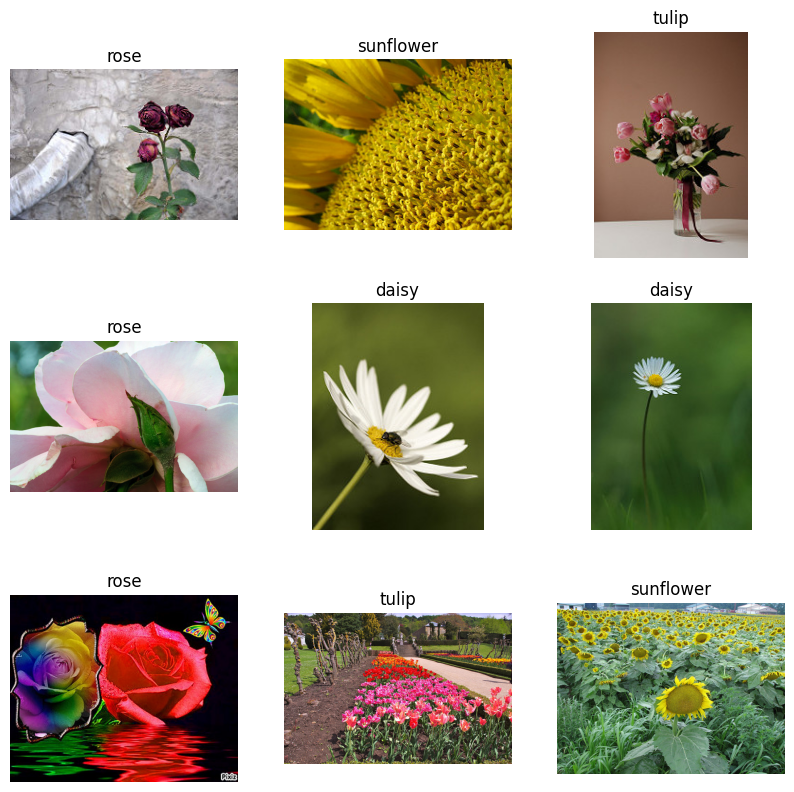

In [8]:
#Show sample images

plt.figure(figsize=(10,10))

for i in range(9):
    cls = random.choice(classes)
    img_path = os.path.join(original_dir, cls, random.choice(os.listdir(os.path.join(original_dir, cls))))

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

##Check for Courrupted Images

In [9]:
#check for the corrupted images
corrupted_images = []  # List to store corrupted image paths

for class_name in classes:
    class_path = os.path.join(original_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Verify image integrity
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

# Print results
if corrupted_images:
    print(f"\n  Corrupted Images Found: {len(corrupted_images)}")
    for img in corrupted_images:
        print(f"   Removing: {img}")
        os.remove(img)
    print(" Corrupted images removed.")
else:
    print("\n No corrupted images found.")


 No corrupted images found.


##Check Class Balance

###A balanced dataset ensures no class dominates the model. If some classes have significantly more images, the model become biased towards those classes.

In [10]:
# Dictionary to store class counts
class_counts = {}

for class_name in classes:
    class_path = os.path.join(original_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

# Print Class Distribution
total = sum(class_counts.values())

print("\nClass Distribution:")
print("=" * 55)
print(f"{'Class Name':<20} {'Image Count':>12} {'Percentage':>12}")
print("=" * 55)
for class_name, count in class_counts.items():
    pct = (count / total) * 100
    print(f"{class_name:<20} {count:>12} {pct:>11.1f}%")
print("=" * 55)
print(f"{'TOTAL':<20} {total:>12} {'100.0%':>12}")


Class Distribution:
Class Name            Image Count   Percentage
dandelion                    1052        24.4%
rose                          784        18.2%
tulip                         984        22.8%
sunflower                     733        17.0%
daisy                         764        17.7%
TOTAL                        4317       100.0%


In my dataset there is not a severe imbalance, so it doesnot require correction.

##Visualize Class Distribution

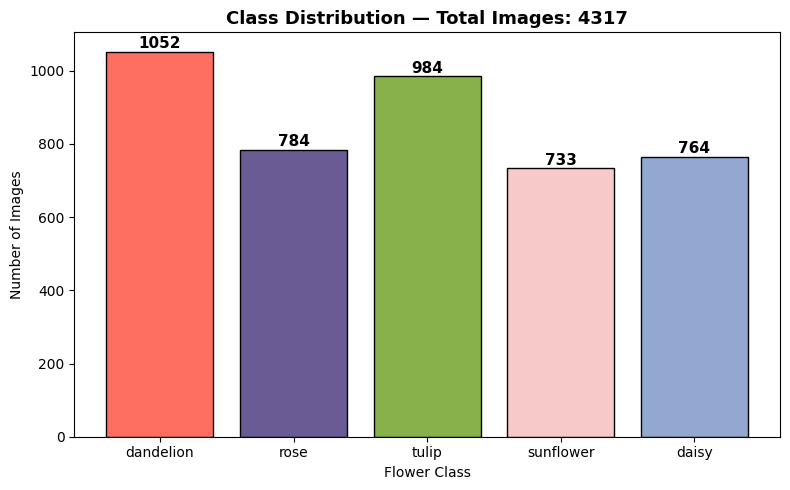

In [77]:
new_colors_bar = ["#FF6F61", "#6B5B95", "#88B04B", "#F7CAC9", "#92A8D1"]
plt.figure(figsize=(8, 5))
bars = plt.bar(class_counts.keys(), class_counts.values(),
               color=new_colors_bar, edgecolor='black')

for bar, count in zip(bars, class_counts.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        str(count), ha='center', fontsize=11, fontweight='bold'
    )

plt.title(f"Class Distribution — Total Images: {total}", fontsize=13, fontweight='bold')
plt.xlabel("Flower Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

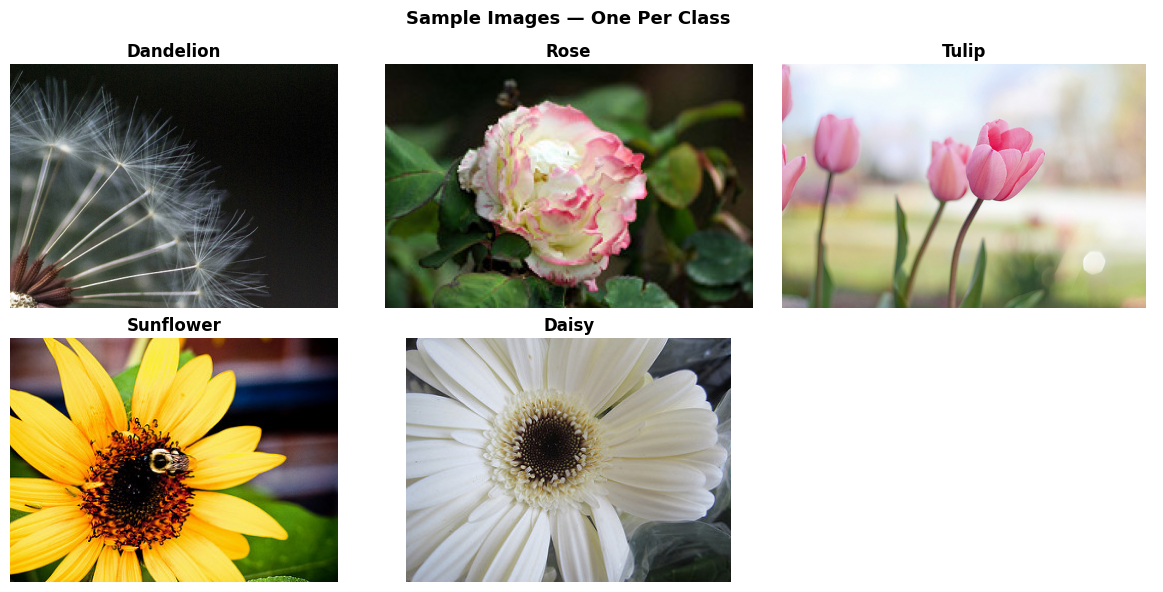

In [12]:
selected_images = []  # Store image paths
selected_labels = []  # Store corresponding class names

for class_name in classes:
    class_path = os.path.join(original_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

# Plot in grid
num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i].capitalize(), fontweight='bold')
        ax.axis("off")
    else:
        ax.axis("off")  # Hide empty subplots

plt.suptitle("Sample Images — One Per Class", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##Split Dataset - Trian, Validation adn Test

In [13]:
import os
import shutil
import random

# # Force a clean split every time this cell is run.
# # If base_dir exists, remove it and its contents.
# if os.path.exists(base_dir):
#     print(" Removing existing split directory to perform a clean split...")
#     shutil.rmtree(base_dir)

# print("Creating split folders...")

# # Create base directory and subdirectories for train, val, test
# os.makedirs(train_dir, exist_ok=True)
# os.makedirs(val_dir, exist_ok=True)
# os.makedirs(test_dir, exist_ok=True)

# # Iterate through each original class folder
# for cls in classes: # Use 'classes' (globally defined) instead of 'class_names' (defined after split)
#     cls_path = os.path.join(original_dir, cls)
#     if os.path.isdir(cls_path):
#         images = [f for f in os.listdir(cls_path)
#                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
#         random.shuffle(images)

#         total_cls  = len(images)
#         train_end  = int(0.70 * total_cls)
#         val_end    = int(0.85 * total_cls)

#         for i, img in enumerate(images):
#             src = os.path.join(cls_path, img)
#             if i < train_end:
#                 dst_dir = os.path.join(train_dir, cls)
#             elif i < val_end:
#                 dst_dir = os.path.join(val_dir, cls)
#             else:
#                 dst_dir = os.path.join(test_dir, cls)

#             os.makedirs(dst_dir, exist_ok=True)
#             shutil.copy(src, os.path.join(dst_dir, img))

# print(" Dataset split complete!")

# # ── Print split summary ──
# print("\nSplit Summary:")
# print("=" * 40)
# print(f"{'Split':<15} {'Images':>10} {'%':>8}")
# print("=" * 40)

# # Recalculate total from original_dir to get correct percentages
# # Use the 'class_counts' dictionary that was populated earlier for the original_dir
# total_original_images = sum(class_counts.values())

# for split_name, split_dir in [("Train", train_dir), ("Validation", val_dir), ("Test", test_dir)]:
#     count = 0
#     if os.path.exists(split_dir):
#         for cls_sub_dir in os.listdir(split_dir):
#             full_cls_path = os.path.join(split_dir, cls_sub_dir)
#             if os.path.isdir(full_cls_path):
#                 count += len(os.listdir(full_cls_path))

#     # Only calculate percentage if total_original_images is not zero to avoid division by zero
#     pct = (count / total_original_images * 100) if total_original_images > 0 else 0.0
#     print(f"{split_name:<15} {count:>10}  {pct:>6.1f}%")
# print("=" * 40)

In [14]:
# ── Only split if not already done ──
if os.path.exists(base_dir) and len(os.listdir(base_dir)) > 0:
    print(" Split already exists — skipping to avoid duplicates.")
else:
    print(" Creating split folders...")

    for folder in [train_dir, val_dir, test_dir]:
        os.makedirs(folder, exist_ok=True)

    for cls in classes:
        cls_path = os.path.join(original_dir, cls)
        if os.path.isdir(cls_path):
            images = [f for f in os.listdir(cls_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            random.shuffle(images)

            total_cls  = len(images)
            train_end  = int(0.70 * total_cls)
            val_end    = int(0.85 * total_cls)

            for i, img in enumerate(images):
                src = os.path.join(cls_path, img)
                if i < train_end:
                    dst_dir = os.path.join(train_dir, cls)
                elif i < val_end:
                    dst_dir = os.path.join(val_dir, cls)
                else:
                    dst_dir = os.path.join(test_dir, cls)

                os.makedirs(dst_dir, exist_ok=True)
                shutil.copy(src, os.path.join(dst_dir, img))

    print(" Dataset split complete!")

# ── Print split summary ──
print("\nSplit Summary:")
print("=" * 40)
print(f"{'Split':<15} {'Images':>10} {'%':>8}")
print("=" * 40)
for split_name, split_dir in [("Train", train_dir), ("Validation", val_dir), ("Test", test_dir)]:
    count = sum(
        len(os.listdir(os.path.join(split_dir, cls)))
        for cls in os.listdir(split_dir)
        if os.path.isdir(os.path.join(split_dir, cls))
    )
    print(f"{split_name:<15} {count:>10}  {count/total*100:>6.1f}%")
print("=" * 40)

 Creating split folders...
 Dataset split complete!

Split Summary:
Split               Images        %
Train                 3019    69.9%
Validation             649    15.0%
Test                   649    15.0%


##Check Class Imbalance After Split

In [15]:
# Update class_names from train_dir after split
class_names = sorted(os.listdir(train_dir))

# Count per class in train
class_counts_train = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts_train[class_name] = len(images)

train_total = sum(class_counts_train.values())

print("\nClass Distribution (Train Set):")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts_train.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution (Train Set):
Class Name               Valid Image Count
daisy                                534
dandelion                            736
rose                                 548
sunflower                            513
tulip                                688


##Data Augmentation

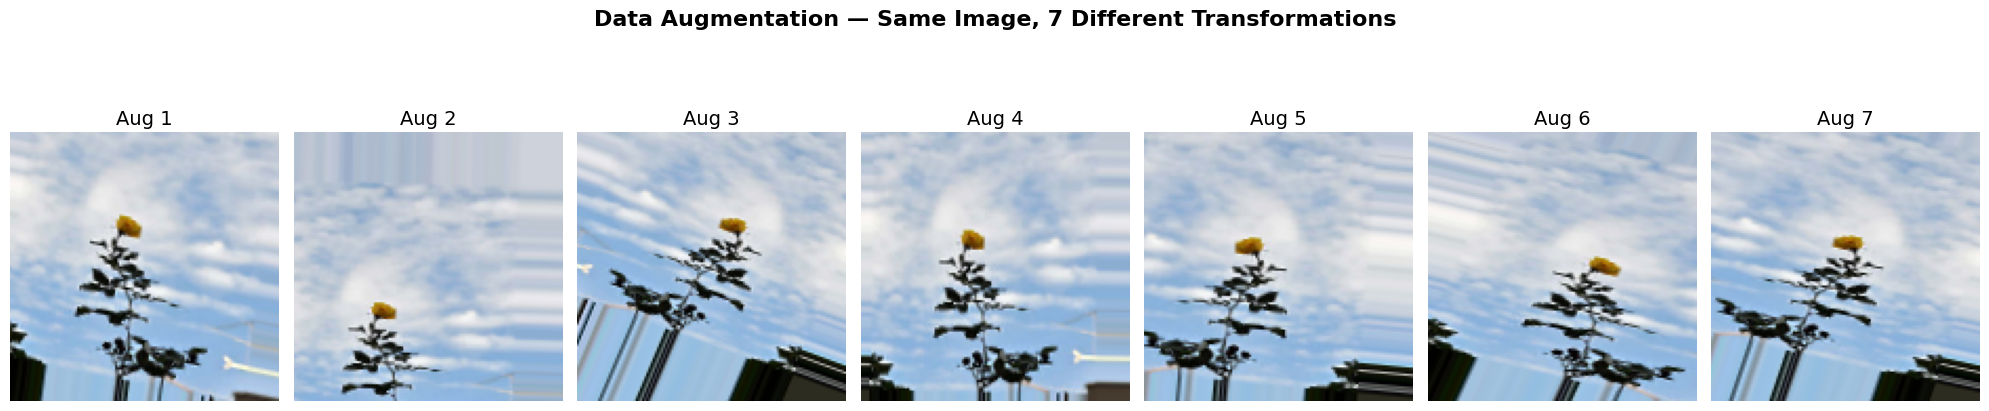

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import numpy as np

datagen = ImageDataGenerator(
    rotation_range=30,       # Rotate images by up to 30 degrees
    width_shift_range=0.2,   # Shift width by 20%
    height_shift_range=0.2,  # Shift height by 20%
    shear_range=0.2,         # Shear transformation
    zoom_range=0.2,          # Zoom in/out by 20%
    horizontal_flip=True,    # Flip images horizontally
    fill_mode='nearest'      # Fill in missing pixels
)

# Load one sample image from train/rose
rose_dir        = os.path.join(train_dir, "rose")
sample_img_name = random.choice(os.listdir(rose_dir))
sample_img_path = os.path.join(rose_dir, sample_img_name)

img = image.load_img(sample_img_path, target_size=IMG_SIZE)
x   = image.img_to_array(img)
x   = np.expand_dims(x, axis=0)

# Generate and visualize 7 augmented images
aug_iter = datagen.flow(x, batch_size=1)

fig, axes = plt.subplots(1, 7, figsize=(20, 5))
fig.suptitle("Data Augmentation — Same Image, 7 Different Transformations",
             fontsize=16, fontweight='bold')

for i in range(7):
    batch = next(aug_iter)
    axes[i].imshow(batch[0].astype('uint8'))
    axes[i].set_title(f"Aug {i+1}", fontsize=14)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


##Create ImageDataGenerator for Training

In [17]:
# ── Training Generator: Augmentation + Normalization ──
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ── Val & Test Generators: Normalization ONLY ──
val_datagen  = ImageDataGenerator(rescale=1.0 / 255)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nClass indices : {train_generator.class_indices}")
print(f"   Train batches : {len(train_generator)}")
print(f"   Val   batches : {len(val_generator)}")
print(f"   Test  batches : {len(test_generator)}")

Found 3019 images belonging to 5 classes.
Found 649 images belonging to 5 classes.
Found 649 images belonging to 5 classes.

Class indices : {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}
   Train batches : 95
   Val   batches : 21
   Test  batches : 21


#Build the Baseline CNN Model

The baseline model structure:
- 3 Convolutional layers (each with MaxPooling)
- 3 Fully Connected (Dense) layers
- 1 Output layer with softmax activation for 5 classes.
- ReLU activation is used for all hidden layers.

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Activation, Dropout

NUM_CLASSES = len(class_names)

#  Baseline CNN Model
baseline_model = Sequential([

    #  Convolutional Block 1
    # 32 filters, 3x3 kernel, ReLU activation
    Conv2D(32, (3, 3), activation='relu', padding='same',
           input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),

    # Convolutional Block 2
    # 64 filters — more filters to learn more complex features
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    #Convolutional Block 3
    # 128 filters — deeper features
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    #Flatten
    # Convert 3D feature maps to 1D vector
    Flatten(),

    # ── Fully Connected Layers ──
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),

    # ── Output Layer
    Dense(NUM_CLASSES, activation='softmax')
])

print(" Baseline model built successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 Baseline model built successfully!


In [19]:
#Model Summary

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,589 (32.51 MB)

 Trainable params: 8,523,589 (32.51 MB)

 Non-trainable params: 0 (0.00 B)

##Compiling the Baseline Model

In [20]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(" Model compiled successfully!")

 Model compiled successfully!


##Train the Model

###We use the Earlystopping to prent from the overfitting and saves training time.

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if val_loss does not improve for 5 consecutive epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

import time
start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

baseline_training_time = time.time() - start_time
print(f"\nTraining time: {baseline_training_time:.2f} seconds")

Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 31s 249ms/step - accuracy: 0.3617 - loss: 1.4002 - val_accuracy: 0.4730 - val_loss: 1.1342
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 209ms/step - accuracy: 0.5267 - loss: 1.1440 - val_accuracy: 0.5362 - val_loss: 1.1237
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 211ms/step - accuracy: 0.5611 - loss: 1.0758 - val_accuracy: 0.6179 - val_loss: 0.9073
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 201ms/step - accuracy: 0.6184 - loss: 0.9738 - val_accuracy: 0.6718 - val_loss: 0.8472
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 213ms/step - accuracy: 0.6492 - loss: 0.9102 - val_accuracy: 0.6965 - val_loss: 0.8255
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 202ms/step - accuracy: 0.6519 - loss: 0.9069 - val_accuracy: 0.6949 - val_loss: 0.8194
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 200ms/step - accuracy: 0.6668 - loss: 0.8594 - val_accuracy: 0.7134 - val_loss: 0.7363
Epoch 8/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 216ms/step - accuracy: 0.6767 - loss: 0.8341 - val_accu

##Plot Traiing vs Validation Loss and Accuracy

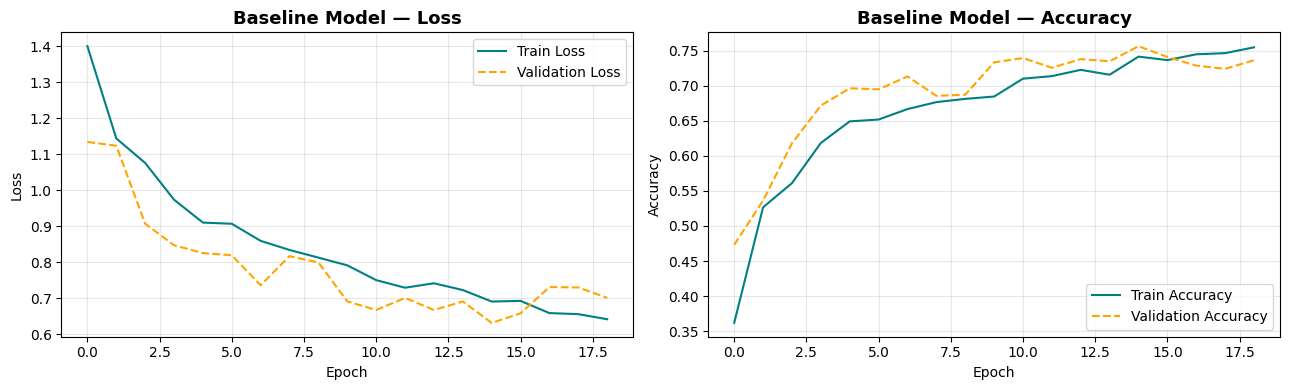

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Loss ──
axes[0].plot(baseline_history.history['loss'],     label='Train Loss',      color='teal')
axes[0].plot(baseline_history.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
axes[0].set_title('Baseline Model — Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Accuracy ──
axes[1].plot(baseline_history.history['accuracy'],     label='Train Accuracy',      color='teal')
axes[1].plot(baseline_history.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--')
axes[1].set_title('Baseline Model — Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("baseline_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

##Evaluate the Model on Test Set

In [23]:
test_loss, test_accuracy = baseline_model.evaluate(test_generator)

print("\n" + "=" * 40)
print(f"  Baseline Model — Test Results")
print("=" * 40)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy * 100:.2f}%")
print("=" * 40)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.7565 - loss: 0.6823

  Baseline Model — Test Results
  Test Loss     : 0.6823
  Test Accuracy : 75.65%


##Classification Report

In [24]:
from sklearn.metrics import classification_report

# Get true labels and predictions
test_generator.reset()
predictions    = baseline_model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = test_generator.classes
class_names      = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print("=" * 60)
print(classification_report(true_labels, predicted_labels,
                             target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step

Classification Report:
              precision    recall  f1-score   support

       daisy       0.83      0.78      0.81       115
   dandelion       0.86      0.75      0.80       158
        rose       0.60      0.76      0.67       118
   sunflower       0.75      0.88      0.81       110
       tulip       0.77      0.64      0.70       148

    accuracy                           0.76       649
   macro avg       0.76      0.76      0.76       649
weighted avg       0.77      0.76      0.76       649



##Confusion Matrix

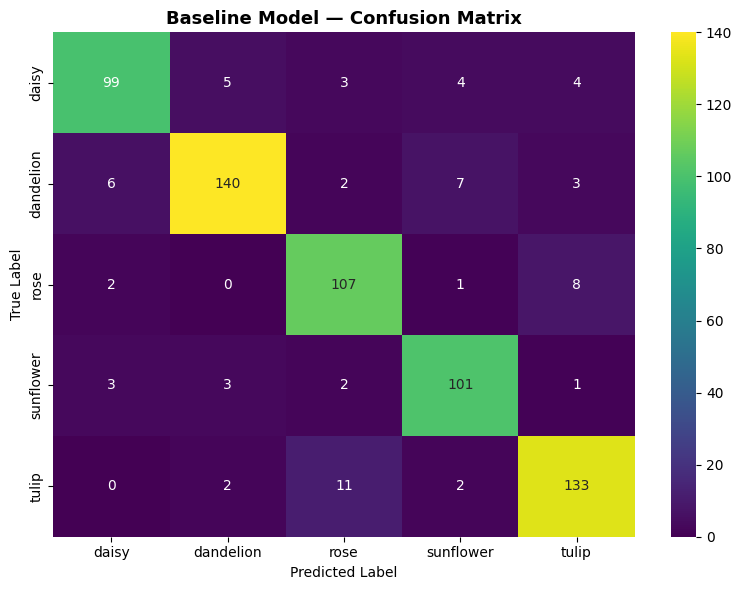

In [66]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', # Changed colormap
            xticklabels=class_names, yticklabels=class_names)
plt.title('Baseline Model — Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig("baseline_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

##Intference on Sample Images

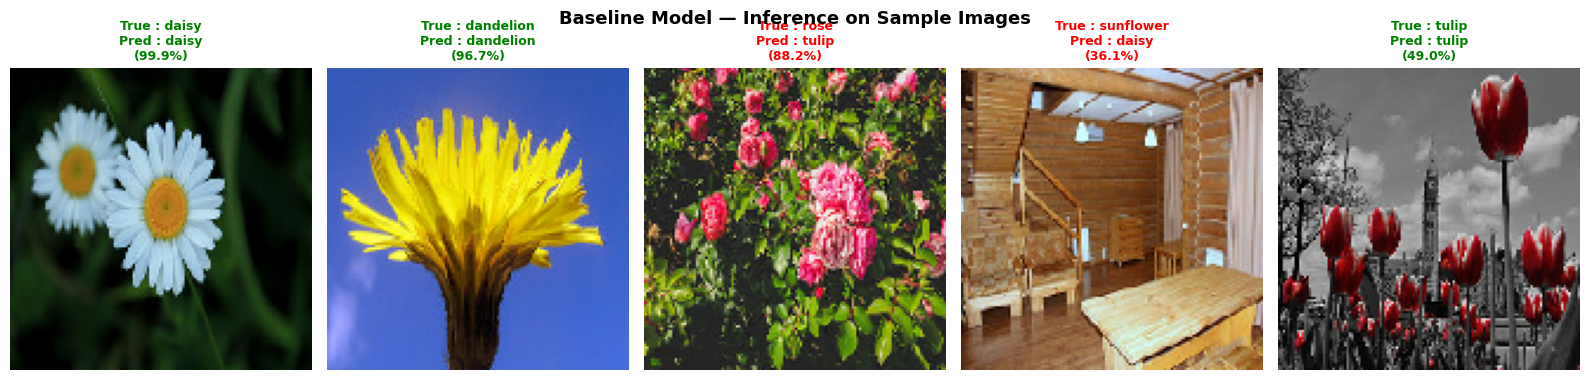


Green title = Correct prediction
   Red title   = Wrong prediction


In [26]:
import random
from tensorflow.keras.preprocessing import image as keras_image

# Pick 5 random images from test set
sample_images = []
sample_labels = []

for class_name in class_names:
    class_path = os.path.join(test_dir, class_name)
    images     = os.listdir(class_path)
    img_name   = random.choice(images)
    sample_images.append(os.path.join(class_path, img_name))
    sample_labels.append(class_name)

# Plot predictions
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle("Baseline Model — Inference on Sample Images",
             fontsize=13, fontweight='bold')

for i, (img_path, true_label) in enumerate(zip(sample_images, sample_labels)):
    # Load and preprocess
    img      = keras_image.load_img(img_path, target_size=IMG_SIZE)
    img_arr  = keras_image.img_to_array(img) / 255.0
    img_arr  = np.expand_dims(img_arr, axis=0)

    # Predict
    pred        = baseline_model.predict(img_arr, verbose=0)
    pred_label  = class_names[np.argmax(pred)]
    confidence  = np.max(pred) * 100

    # Plot
    axes[i].imshow(keras_image.load_img(img_path, target_size=IMG_SIZE))
    axes[i].axis('off')

    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(
        f"True : {true_label}\nPred : {pred_label}\n({confidence:.1f}%)",
        fontsize=9, color=color, fontweight='bold'
    )

plt.tight_layout()
plt.savefig("baseline_inference.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nGreen title = Correct prediction")
print("   Red title   = Wrong prediction")

##Save the Baseline CNN model

In [27]:
baseline_model.save("baseline_model.h5")
print("Baseline model saved as baseline_model.h5")

Baseline model saved as baseline_model.h5


#Build the Deeper CNN Model

Compared to the baseline (3 conv layers), this model has **6 convolutional layers** — double the depth.

Two new techniques are added:

**BatchNormalization:**
- Normalizes the output of each layer during training
- Helps the model train faster and more stably
- Reduces sensitivity to weight initialization

**Dropout:**
- Randomly switches off a fraction of neurons during training
- Prevents the model from memorizing training data (overfitting)
- `Dropout(0.25)` = 25% of neurons are switched off per step

In [28]:
def build_deeper_model(optimizer):
    """
    Builds and compiles the deeper CNN model.
    optimizer: pass 'adam' or SGD() object
    """
    model = Sequential([

        # ── Conv Block 1 ── (32 filters)
        Conv2D(32, (3, 3), padding='same', input_shape=(128, 128, 3)),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # ── Conv Block 2 ── (64 filters)
        Conv2D(64, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # ── Conv Block 3 ── (128 filters)
        Conv2D(128, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # ── Conv Block 4 ── (256 filters)
        Conv2D(256, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # ── Conv Block 5 ── (512 filters)
        Conv2D(512, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # ── Conv Block 6 ── (512 filters)
        Conv2D(512, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.2),

        # ── Flatten ──
        Flatten(),

        # ── Fully Connected Layers ──
        Dense(400),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.3),

        Dense(200),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.3),

        Dense(100),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.3),

        # ── Output Layer ──
        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("build_deeper_model() function defined.")

build_deeper_model() function defined.


##Compile the MOdel

# Model Summary

In [29]:
# Print summary using Adam (architecture is same regardless of optimizer)
temp_model = build_deeper_model('adam')
temp_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 7,315,205 (27.91 MB)

 Trainable params: 7,310,797 (27.89 MB)

 Non-trainable params: 4,408 (17.22 KB)

##Train the Model

In [30]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import time

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

# Build with Adam
model_adam = build_deeper_model(optimizer=Adam(learning_rate=0.0005))

print("Training Deeper Model with ADAM...")
start_adam = time.time()

history_adam = model_adam.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

time_adam = time.time() - start_adam
print(f"\n Adam Training Time: {time_adam:.2f} seconds")

Training Deeper Model with ADAM...
Epoch 1/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 57s 399ms/step - accuracy: 0.3607 - loss: 1.6269 - val_accuracy: 0.2435 - val_loss: 4.1614
Epoch 2/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 217ms/step - accuracy: 0.4624 - loss: 1.3308 - val_accuracy: 0.2435 - val_loss: 4.3074
Epoch 3/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 235ms/step - accuracy: 0.5055 - loss: 1.2224 - val_accuracy: 0.2435 - val_loss: 4.1894
Epoch 4/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 228ms/step - accuracy: 0.5492 - loss: 1.1492 - val_accuracy: 0.2435 - val_loss: 3.5050
Epoch 5/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 226ms/step - accuracy: 0.5777 - loss: 1.0639 - val_accuracy: 0.2450 - val_loss: 3.9308
Epoch 6/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 215ms/step - accuracy: 0.5982 - loss: 1.0053 - val_accuracy: 0.3421 - val_loss: 2.1874
Epoch 7/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 236ms/step - accuracy: 0.6154 - loss: 0.9957 - val_accuracy: 0.4391 - val_loss: 2.0108
Epoch 8/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 217ms/step - accurac

##Adam Plot Trainign vs Vlidation Loss and Accuracy

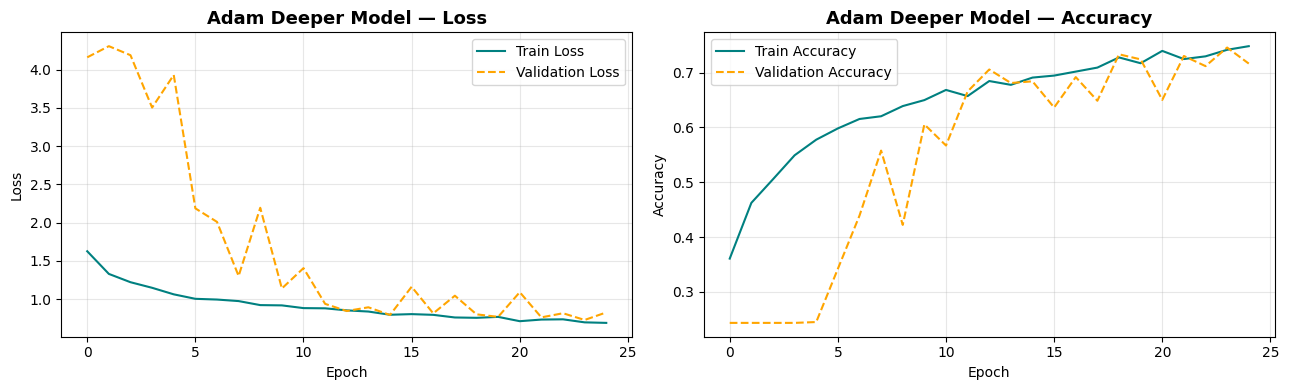

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(history_adam.history['loss'],     label='Train Loss',      color='teal')
axes[0].plot(history_adam.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
axes[0].set_title('Adam Deeper Model — Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history_adam.history['accuracy'],     label='Train Accuracy',      color='teal')
axes[1].plot(history_adam.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--')
axes[1].set_title('Adam Deeper Model — Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("deeper_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

#Train Deepr Model with SGD Optimizer

In [32]:
from tensorflow.keras.optimizers import SGD

# Build with SG
model_sgd = build_deeper_model(
    optimizer=SGD(learning_rate=0.0005, momentum=0.9)
)

print("Training Deeper Model with SGD...")
start_sgd = time.time()

history_sgd = model_sgd.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

time_sgd = time.time() - start_sgd
print(f"\n SGD Training Time: {time_sgd:.2f} seconds")

Training Deeper Model with SGD...
Epoch 1/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 49s 361ms/step - accuracy: 0.2763 - loss: 1.8181 - val_accuracy: 0.2435 - val_loss: 1.9314
Epoch 2/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 210ms/step - accuracy: 0.3640 - loss: 1.5646 - val_accuracy: 0.2435 - val_loss: 2.3685
Epoch 3/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 231ms/step - accuracy: 0.4203 - loss: 1.4327 - val_accuracy: 0.2435 - val_loss: 2.6054
Epoch 4/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 213ms/step - accuracy: 0.4465 - loss: 1.3745 - val_accuracy: 0.2435 - val_loss: 2.5093
Epoch 5/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 230ms/step - accuracy: 0.4621 - loss: 1.3191 - val_accuracy: 0.2527 - val_loss: 2.4200
Epoch 6/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 238ms/step - accuracy: 0.4849 - loss: 1.2904 - val_accuracy: 0.2558 - val_loss: 2.2892

 SGD Training Time: 175.46 seconds


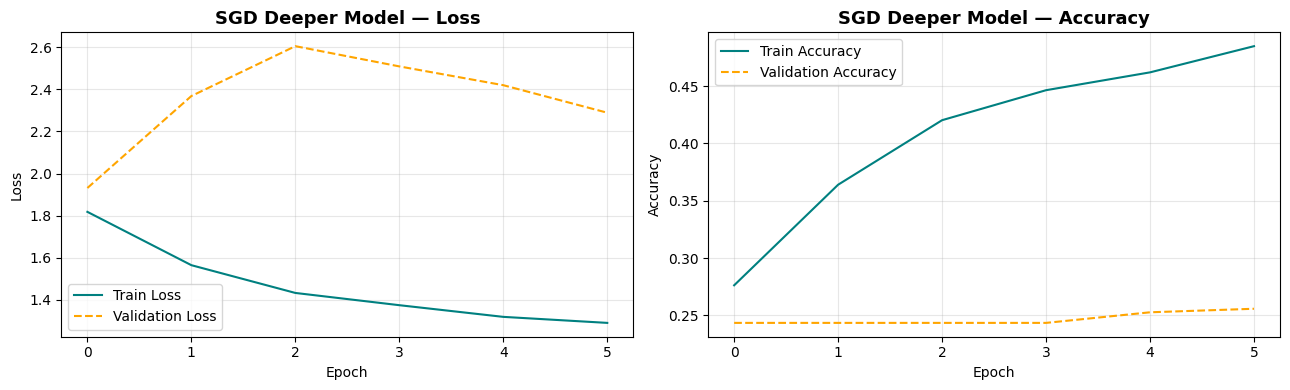

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(history_sgd.history['loss'],     label='Train Loss',      color='teal')
axes[0].plot(history_sgd.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
axes[0].set_title('SGD Deeper Model — Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history_sgd.history['accuracy'],     label='Train Accuracy',      color='teal')
axes[1].plot(history_sgd.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--')
axes[1].set_title('SGD Deeper Model — Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("deeper_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

##Compare Performance of Adam vs SGD - Training Curves

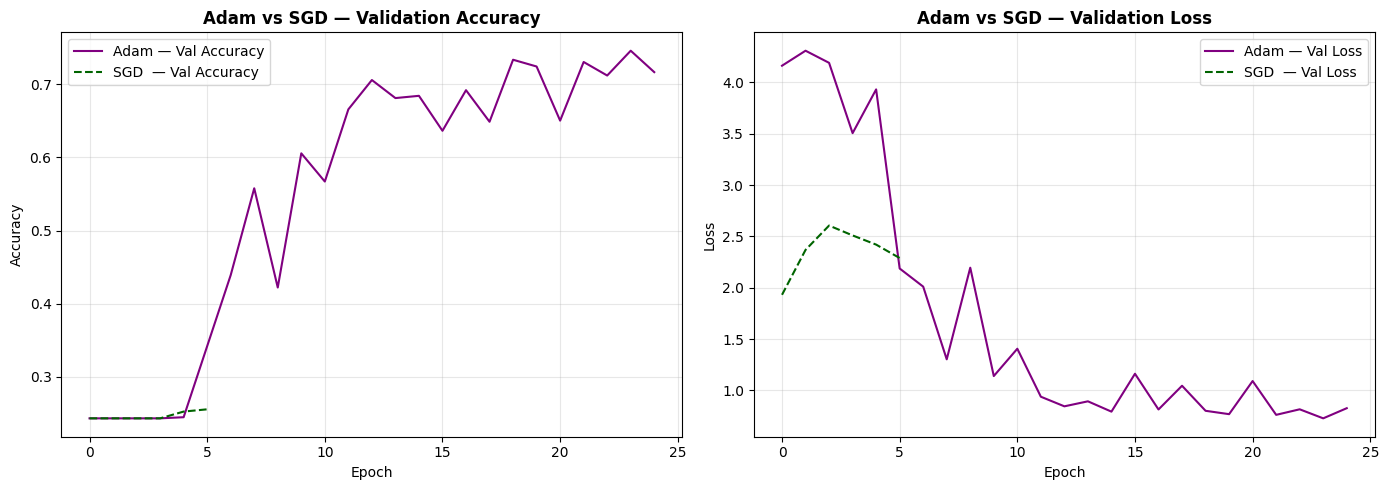

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy ──
axes[0].plot(history_adam.history['val_accuracy'],
             label='Adam — Val Accuracy', color='purple') # Changed color
axes[0].plot(history_sgd.history['val_accuracy'],
             label='SGD  — Val Accuracy', color='darkgreen', linestyle='--') # Changed color
axes[0].set_title('Adam vs SGD — Validation Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Loss ──
axes[1].plot(history_adam.history['val_loss'],
             label='Adam — Val Loss', color='purple') # Changed color
axes[1].plot(history_sgd.history['val_loss'],
             label='SGD  — Val Loss', color='darkblue', linestyle='--') # Changed color
axes[1].set_title('Adam vs SGD — Validation Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("adam_vs_sgd.png", dpi=150, bbox_inches='tight')
plt.show()

SGD's fixed learning rate led to fluctuating validation loss and early termination by EarlyStopping. Adam, with its adaptive learning rate, showed more stable convergence, trained longer, and achieved better results.

##Evaluate both optimizer on Test Set

In [35]:


loss_adam, acc_adam = model_adam.evaluate(test_generator, verbose=0)
loss_sgd,  acc_sgd  = model_sgd.evaluate(test_generator,  verbose=0)

print("=" * 50)
print(f"{'Metric':<20} {'Adam':>12} {'SGD':>12}")
print("=" * 50)
print(f"{'Test Accuracy':<20} {acc_adam*100:>11.2f}% {acc_sgd*100:>11.2f}%")
print(f"{'Test Loss':<20} {loss_adam:>12.4f} {loss_sgd:>12.4f}")
print(f"{'Training Time (s)':<20} {time_adam:>12.2f} {time_sgd:>12.2f}")
print("=" * 50)

Metric                       Adam          SGD
Test Accuracy              71.96%       24.35%
Test Loss                  0.7383       1.9313
Training Time (s)          704.39       175.46


##Comparision between Baseline vs Deeper Model(Adam)

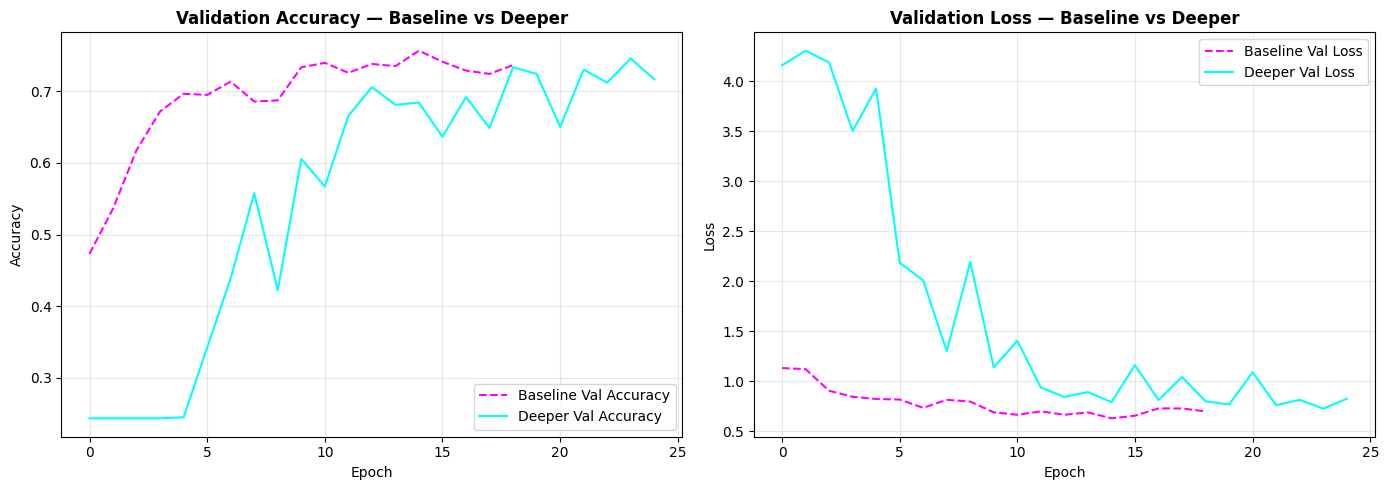

In [70]:
# ── Load baseline history (must have run Stage 2 first) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy Comparison ──
axes[0].plot(baseline_history.history['val_accuracy'],
             label='Baseline Val Accuracy', color='magenta', linestyle='--') # Changed color
axes[0].plot(history_adam.history['val_accuracy'],
             label='Deeper Val Accuracy',   color='cyan') # Changed color
axes[0].set_title('Validation Accuracy — Baseline vs Deeper', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Loss Comparison ──
axes[1].plot(baseline_history.history['val_loss'],
             label='Baseline Val Loss', color='magenta', linestyle='--') # Changed color
axes[1].plot(history_adam.history['val_loss'],
             label='Deeper Val Loss',   color='cyan') # Changed color
axes[1].set_title('Validation Loss — Baseline vs Deeper', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("baseline_vs_deeper.png", dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# ── Get baseline results (from Stage 2) ──
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(test_generator, verbose=0)
loss_adam,   acc_adam   = model_adam.evaluate(test_generator,   verbose=0)

print("=" * 55)
print(f"{'Metric':<25} {'Baseline':>12} {'Deeper':>12}")
print("=" * 55)
print(f"{'Test Accuracy':<25} {baseline_test_acc*100:>11.2f}% {acc_adam*100:>11.2f}%")
print(f"{'Test Loss':<25} {baseline_test_loss:>12.4f} {loss_adam:>12.4f}")
print(f"{'Training Time (s)':<25} {baseline_training_time:>12.2f} {time_adam:>12.2f}")



Metric                        Baseline       Deeper
Test Accuracy                   75.65%       71.96%
Test Loss                       0.6823       0.7383
Training Time (s)               408.31       704.39


#Ablation Study - Remove Dropout

In [38]:
# ── Model WITHOUT Dropout ──
model_no_dropout = Sequential([

    Conv2D(32, (3, 3), padding='same', input_shape=(128, 128, 3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(512, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(512, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    Flatten(),

    Dense(400),
    BatchNormalization(),
    Activation('relu'),

    Dense(200),
    BatchNormalization(),
    Activation('relu'),

    Dense(100),
    BatchNormalization(),
    Activation('relu'),

    Dense(NUM_CLASSES, activation='softmax')
])

#Compile the model

model_no_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training model WITHOUT Dropout...")
start_ablation = time.time()

history_no_dropout = model_no_dropout.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

time_ablation = time.time() - start_ablation
print(f"\nAblation Training Time: {time_ablation:.2f} seconds")

Training model WITHOUT Dropout...
Epoch 1/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 303ms/step - accuracy: 0.5224 - loss: 1.1800 - val_accuracy: 0.2435 - val_loss: 3.0074
Epoch 2/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 234ms/step - accuracy: 0.5883 - loss: 1.0234 - val_accuracy: 0.2435 - val_loss: 4.0650
Epoch 3/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 236ms/step - accuracy: 0.6403 - loss: 0.9387 - val_accuracy: 0.2465 - val_loss: 4.2458
Epoch 4/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 214ms/step - accuracy: 0.6585 - loss: 0.8732 - val_accuracy: 0.3066 - val_loss: 2.7302
Epoch 5/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 219ms/step - accuracy: 0.6780 - loss: 0.8456 - val_accuracy: 0.5994 - val_loss: 1.1668
Epoch 6/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 219ms/step - accuracy: 0.6823 - loss: 0.8335 - val_accuracy: 0.6995 - val_loss: 0.8366

Ablation Training Time: 166.28 seconds


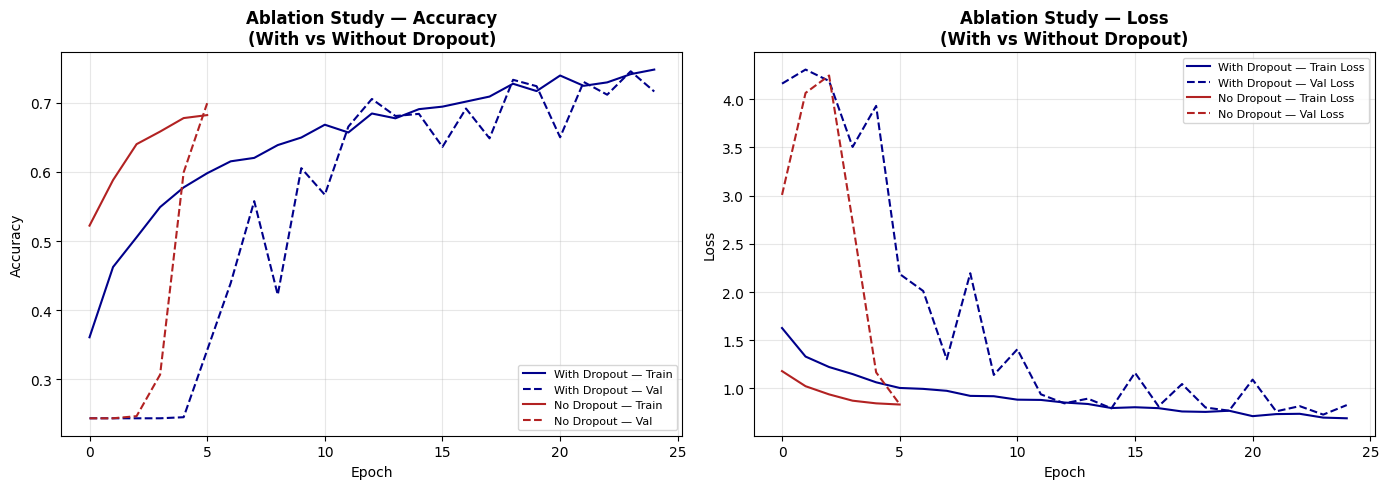

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy ──
axes[0].plot(history_adam.history['train_accuracy'] if 'train_accuracy' in history_adam.history else history_adam.history['accuracy'],
             label='With Dropout — Train', color='darkblue') # Changed color
axes[0].plot(history_adam.history['val_accuracy'],
             label='With Dropout — Val', color='darkblue', linestyle='--') # Changed color
axes[0].plot(history_no_dropout.history['accuracy'],
             label='No Dropout — Train', color='firebrick') # Changed color
axes[0].plot(history_no_dropout.history['val_accuracy'],
             label='No Dropout — Val', color='firebrick', linestyle='--') # Changed color
axes[0].set_title('Ablation Study — Accuracy\n(With vs Without Dropout)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# ── Loss ──
axes[1].plot(history_adam.history['loss'],
             label='With Dropout — Train Loss', color='darkblue') # Changed color
axes[1].plot(history_adam.history['val_loss'],
             label='With Dropout — Val Loss', color='darkblue', linestyle='--') # Changed color
axes[1].plot(history_no_dropout.history['loss'],
             label='No Dropout — Train Loss', color='firebrick') # Changed color
axes[1].plot(history_no_dropout.history['val_loss'],
             label='No Dropout — Val Loss', color='firebrick', linestyle='--') # Changed color
axes[1].set_title('Ablation Study — Loss\n(With vs Without Dropout)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ablation_study.png", dpi=150, bbox_inches='tight')
plt.show()

From the above graph we can tell that Dropout plays a crucial role in this model. Without Dropout, the model trained very quickly in the first five epoch buth triggered EarlyStopping due to the unstable validation loss, indicating overfitting.

In [40]:
# Evaluate all models on test set
test_generator.reset()
loss_baseline, acc_baseline     = baseline_model.evaluate(test_generator, verbose=0)
test_generator.reset()
loss_adam, acc_adam             = model_adam.evaluate(test_generator, verbose=0)
test_generator.reset()
loss_sgd, acc_sgd               = model_sgd.evaluate(test_generator, verbose=0)
test_generator.reset()
loss_no_drop, acc_no_drop       = model_no_dropout.evaluate(test_generator, verbose=0)

print("=" * 70)
print(f"{'Model':<25} {'Test Acc':>10} {'Test Loss':>12} {'Train Time(s)':>15}")
print("=" * 70)
print(f"{'Baseline CNN':<25} {acc_baseline*100:>9.2f}% {loss_baseline:>12.4f} {baseline_training_time:>15.2f}")
print(f"{'Deeper + Adam':<25} {acc_adam*100:>9.2f}% {loss_adam:>12.4f} {time_adam:>15.2f}")
print(f"{'Deeper + SGD':<25} {acc_sgd*100:>9.2f}% {loss_sgd:>12.4f} {time_sgd:>15.2f}")
print(f"{'Deeper (No Dropout)':<25} {acc_no_drop*100:>9.2f}% {loss_no_drop:>12.4f} {time_ablation:>15.2f}")
print("=" * 70)

Model                       Test Acc    Test Loss   Train Time(s)
Baseline CNN                  75.65%       0.6823          408.31
Deeper + Adam                 71.96%       0.7383          704.39
Deeper + SGD                  24.35%       1.9313          175.46
Deeper (No Dropout)           24.35%       2.9997          166.28


##Classification Report

In [41]:
test_generator.reset()
predictions      = model_adam.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = test_generator.classes
class_names      = list(test_generator.class_indices.keys())

print("Classification Report — Deeper Model (Adam):")
print("=" * 60)
print(classification_report(true_labels, predicted_labels,
                             target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step
Classification Report — Deeper Model (Adam):
              precision    recall  f1-score   support

       daisy       0.88      0.72      0.79       115
   dandelion       0.65      0.94      0.77       158
        rose       0.56      0.77      0.65       118
   sunflower       0.92      0.62      0.74       110
       tulip       0.85      0.51      0.64       148

    accuracy                           0.72       649
   macro avg       0.77      0.71      0.72       649
weighted avg       0.77      0.72      0.72       649



##Confusion Matrix

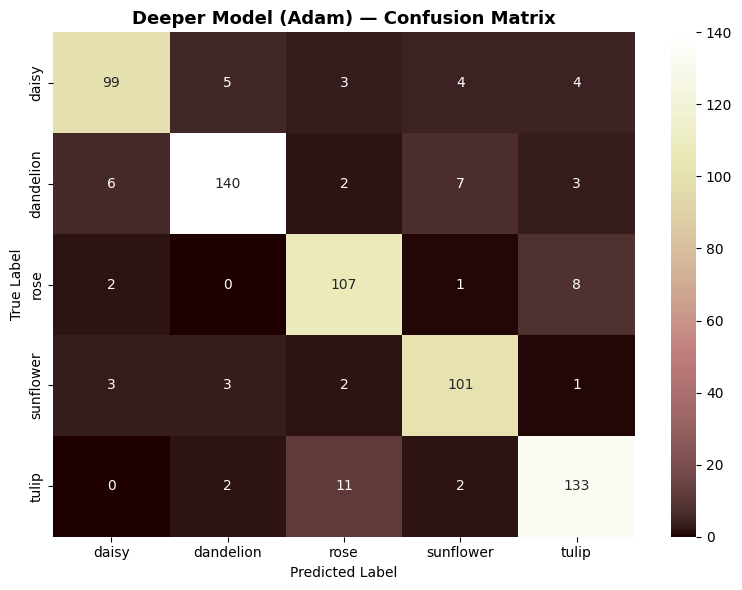

In [101]:
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='pink', # Changed colormap
            xticklabels=class_names, yticklabels=class_names)
plt.title('Deeper Model (Adam) — Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig("deeper_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

##Summary Table - Baseline vs Deeper

In [43]:
print("=" * 60)
print("  Challenges and Observations Summary")
print("=" * 60)
print(f"  Hardware Used        : Google Colab (GPU)")
print(f"  Baseline Train Time  : {baseline_training_time:.2f} seconds")
print(f"  Deeper (Adam) Time   : {time_adam:.2f} seconds")
print(f"  Deeper (SGD) Time    : {time_sgd:.2f} seconds")
print(f"  Ablation Time        : {time_ablation:.2f} seconds")
print("=" * 60)
print("\n  Key Observations:")
print("  - Deeper model takes longer to train due to more layers")
print("  - Adam converges faster than SGD")
print("  - Dropout reduces overfitting (train/val gap is smaller)")
print("  - Model without Dropout shows higher train acc but lower val acc")
print("=" * 60)

  Challenges and Observations Summary
  Hardware Used        : Google Colab (GPU)
  Baseline Train Time  : 408.31 seconds
  Deeper (Adam) Time   : 704.39 seconds
  Deeper (SGD) Time    : 175.46 seconds
  Ablation Time        : 166.28 seconds

  Key Observations:
  - Deeper model takes longer to train due to more layers
  - Adam converges faster than SGD
  - Dropout reduces overfitting (train/val gap is smaller)
  - Model without Dropout shows higher train acc but lower val acc


**Key Observations:**
- Deeper model training time is longer than baseline.
- Adam outperforms SGD.
- Dropout prevents overfitting (improves validation accuracy).
- Model without Dropout overfits (higher train acc, lower val acc).

##Save the Deeper Model

In [44]:
model_adam.save("deeper_model_adam.h5")
model_sgd.save("deeper_model_sgd.h5")
print("Both models saved successfully!")

Both models saved successfully!


# Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)

In [81]:
import os

# Ensure these paths are consistent with data splitting (in /content/split_data)
# original_dir might be used in earlier cells, so we'll keep it as is from user context.
# base_dir is already set correctly in 2a282938 for data generators.

# Correcting paths to use the local split data, as was resolved earlier
base_dir     = "/content/split_data"
train_dir    = os.path.join(base_dir, "train")
val_dir      = os.path.join(base_dir, "val")
test_dir     = os.path.join(base_dir, "test")

# IMG_SIZE needs to be (224, 224) for MobileNetV2 input requirements
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 5

print(f"Image size set to {IMG_SIZE} to match MobileNetV2 input requirements")

Image size set to (224, 224) to match MobileNetV2 input requirements


In [82]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input # Changed to MobileNetV2 preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os # Added import os for directory checks

# Re-define paths to point to where the data was actually split (in /content)
# This overrides the paths set in jDKm8BkCvU4v to resolve FileNotFoundError.
base_dir  = "/content/split_data"
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

# The previous check for FileNotFoundError is removed as paths are being corrected.
# if not os.path.exists(train_dir):
#     print(f"Error: The directory '{train_dir}' was not found. Please ensure you have run cell 'f_WJqaiG1cx1' to perform the data splitting before executing this cell.")
#     raise FileNotFoundError(f"Directory not found: {train_dir}. Please run data splitting cell 'f_WJqaiG1cx1'.")

# ── Training Generator: Augmentation + MobileNetV2 Preprocessing ──
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # MobileNetV2 specific normalization
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ── Val & Test: MobileNetV2 Preprocessing ONLY ──
val_datagen  = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nClass indices : {train_generator.class_indices}")
print(f"   Train batches : {len(train_generator)}")
print(f"   Val   batches : {len(val_generator)}")
print(f"   Test  batches : {len(test_generator)}")

Found 3019 images belonging to 5 classes.
Found 649 images belonging to 5 classes.
Found 649 images belonging to 5 classes.

Class indices : {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}
   Train batches : 95
   Val   batches : 21
   Test  batches : 21


##Create Data Genreators

We create new generators with 224x224 image size to match VGG16 input requirements.

##Load VGG16 Pre-Trained Model



In [83]:
# from tensorflow.keras.applications.vgg16 import VGG16
# # Load VGG16 without the top classification layer
# base_model = VGG16(
#     weights='imagenet',
#     include_top=False,
#     input_shape=(224, 224, 3)
# )

# print(" VGG16 loaded successfully!")
# print(f"   Total layers in VGG16: {len(base_model.layers)}")

print("VGG16 model loading has been removed as per user request.")

VGG16 model loading has been removed as per user request.


## VGG16 Layer Freezing (Removed)

This section has been removed as per your request to exclude VGG16 from the analysis.

In [84]:
# # Freeze ALL layers of VGG16
# for layer in base_model.layers:
#     layer.trainable = False

# # Verify frozen layers
# print(f"Total layers     : {len(base_model.layers)}")
# print(f"Trainable layers : {sum(1 for l in base_model.layers if l.trainable)}")
# print(f"Frozen layers    : {sum(1 for l in base_model.layers if not l.trainable)}")

print("VGG16 layer freezing code removed.")

VGG16 layer freezing code removed.


## Custom Layers for VGG16 (Removed)

This section has been removed as per your request to exclude VGG16 from the analysis.

In [85]:
# from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
# from tensorflow.keras.models import Model

# # Add custom layers on top of VGG16
# x = base_model.output
# x = GlobalAveragePooling2D()(x)          # Reduce spatial dimensions
# x = Dense(200, activation='relu')(x)     # Fully connected layer
# x = Dropout(0.3)(x)                      # Regularization
# output = Dense(NUM_CLASSES, activation='softmax')(x)  # 5 flower classes

# # Create the final model
# model_tl = Model(inputs=base_model.input, outputs=output)

# print("Custom model created!")
# print(f"   Total layers     : {len(model_tl.layers)}")
# print(f"   Trainable layers : {sum(1 for l in model_tl.layers if l.trainable)}")
# print(f"   Frozen layers    : {sum(1 for l in model_tl.layers if not l.trainable)}")

print("VGG16 custom layers code removed.")

VGG16 custom layers code removed.


In [86]:
# model_tl.summary()
print("VGG16 model summary removed.")

VGG16 model summary removed.


## Compile and Train - 1. VGG16 Feature Extraction (Removed)

This section has been removed as per your request to exclude VGG16 from the analysis.

In [87]:
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping
# import time

# # Compile
# model_tl.compile(
#     optimizer=Adam(learning_rate=0.0005),
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# early_stopping = EarlyStopping(
#     monitor='val_loss',
#     patience=6,
#     restore_best_weights=True
# )

# print("Training Strategy 1: Feature Extraction...")
# start_fe = time.time()

# history_fe = model_tl.fit(
#     train_generator,
#     epochs=20,
#     validation_data=val_generator,
#     callbacks=[early_stopping]
# )

# time_fe = time.time() - start_fe
# print(f"\n Feature Extraction Training Time: {time_fe:.2f} seconds")

# Set placeholder values for consistency in summary table if needed later
acc_tl = 0.0
loss_tl = 0.0
time_fe = 0.0
print("VGG16 Feature Extraction training code removed.")

VGG16 Feature Extraction training code removed.


## Plot Training Curves - VGG16 Feature Extraction (Removed)

This section has been removed as per your request to exclude VGG16 from the analysis.

In [88]:
# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# axes[0].plot(history_fe.history['loss'],     label='Train Loss',      color='teal')
# axes[0].plot(history_fe.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
# axes[0].set_title('Feature Extraction — Loss', fontsize=13, fontweight='bold')
# axes[0].set_xlabel('Epoch')
# axes[0].set_ylabel('Loss')
# axes[0].legend()
# axes[0].grid(alpha=0.3)

# axes[1].plot(history_fe.history['accuracy'],     label='Train Accuracy',      color='teal')
# axes[1].plot(history_fe.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--')
# axes[1].set_title('Feature Extraction — Accuracy', fontsize=13, fontweight='bold')
# axes[1].set_xlabel('Epoch')
# axes[1].set_ylabel('Accuracy')
# axes[1].legend()
# axes[1].grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig("feature_extraction_curves.png", dpi=150, bbox_inches='tight')
# plt.show()

print("VGG16 Feature Extraction plotting code removed.")

VGG16 Feature Extraction plotting code removed.


## Evaluate - VGG16 Feature Extraction (Removed)

This section has been removed as per your request to exclude VGG16 from the analysis.

In [89]:
# loss_tl, acc_tl = model_tl.evaluate(test_generator, verbose=0)

# print("\n" + "=" * 45)
# print("  Strategy 1: Feature Extraction Results")
# print("=" * 45)
# print(f"  Test Loss     : {loss_tl:.4f}")
# print(f"  Test Accuracy : {acc_tl * 100:.2f}%")
# print("=" * 45)

print("VGG16 Feature Extraction evaluation code removed.")

VGG16 Feature Extraction evaluation code removed.


## 2. VGG16 Fine Tuning (Removed)

This section has been removed as per your request to exclude VGG16 from the analysis.

In [90]:
# for layer in model_tl.layers:
#     layer.trainable = False       # freeze all first

# for layer in model_tl.layers[-2:]:  # unfreeze last 4
#     layer.trainable = True

# # Verify
# print(f"Total layers     : {len(model_tl.layers)}")
# print(f"Trainable layers : {sum(1 for l in model_tl.layers if l.trainable)}")
# print(f"Frozen layers    : {sum(1 for l in model_tl.layers if not l.trainable)}")

# # Print which layers are trainable
# print("\nTrainable layer names:")
# for layer in model_tl.layers:
#     if layer.trainable:
#         print(f" {layer.name}")

# Set placeholder values for consistency in summary table if needed later
acc_ft = 0.0
loss_ft = 0.0
time_ft = 0.0
print("VGG16 Fine-tuning setup code removed.")

VGG16 Fine-tuning setup code removed.


In [91]:
# # Recompile with VERY LOW learning rate
# model_tl.compile(
#     optimizer=Adam(learning_rate=0.00005),   # 10x lower than feature extraction
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# early_stopping_ft = EarlyStopping(
#     monitor='val_loss',
#     patience=6,
#     restore_best_weights=True
# )

# print("Training Strategy 2: Fine Tuning...")
# start_ft = time.time()

# history_ft = model_tl.fit(
#     train_generator,
#     epochs=20,
#     validation_data=val_generator,
#     callbacks=[early_stopping_ft]
# )

# time_ft = time.time() - start_ft
# print(f"\n Fine Tuning Training Time: {time_ft:.2f} seconds")

print("VGG16 Fine-tuning training code removed.")

VGG16 Fine-tuning training code removed.


In [92]:
# fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# axes[0].plot(history_ft.history['loss'],     label='Train Loss',      color='teal')
# axes[0].plot(history_ft.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
# axes[0].set_title('Fine Tuning — Loss', fontsize=13, fontweight='bold')
# axes[0].set_xlabel('Epoch')
# axes[0].set_ylabel('Loss')
# axes[0].legend()
# axes[0].grid(alpha=0.3)

# axes[1].plot(history_ft.history['accuracy'],     label='Train Accuracy',      color='teal')
# axes[1].plot(history_ft.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--')
# axes[1].set_title('Fine Tuning — Accuracy', fontsize=13, fontweight='bold')
# axes[1].set_xlabel('Epoch')
# axes[1].set_ylabel('Accuracy')
# axes[1].legend()
# axes[1].grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig("fine_tuning_curves.png", dpi=150, bbox_inches='tight')
# plt.show()

print("VGG16 Fine-tuning plotting code removed.")

VGG16 Fine-tuning plotting code removed.


In [93]:
# loss_ft, acc_ft = model_tl.evaluate(test_generator, verbose=0)

# print("\n" + "=" * 45)
# print("  Strategy 2: Fine Tuning Results")
# print("=" * 45)
# print(f"  Test Loss     : {loss_ft:.4f}")
# print(f"  Test Accuracy : {acc_ft * 100:.2f}%")
# print("=" * 45)

print("VGG16 Fine-tuning evaluation code removed.")

VGG16 Fine-tuning evaluation code removed.


In [94]:
# import numpy as np
# from sklearn.metrics import classification_report

# # Reset before predicting
# test_generator.reset()

# predictions      = model_tl.predict(test_generator)
# predicted_labels = np.argmax(predictions, axis=1)
# true_labels      = test_generator.classes
# class_names      = list(test_generator.class_indices.keys())

# print(f"Predictions : {len(predicted_labels)}")
# print(f"True labels : {len(true_labels)}")

# print("\nClassification Report:")
# print("=" * 60)
# print(classification_report(true_labels, predicted_labels,
#                              target_names=class_names))

print("VGG16 classification report code removed.")

VGG16 classification report code removed.


In [95]:
# from sklearn.metrics import confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

# cm = confusion_matrix(true_labels, predicted_labels)

# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='cubehelix', # Changed colormap
#             xticklabels=class_names, yticklabels=class_names)
# plt.title('Transfer Learning (VGG16) — Confusion Matrix',
#           fontsize=13, fontweight='bold')
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.tight_layout()
# plt.savefig("transfer_learning_confusion_matrix.png", dpi=150, bbox_inches='tight')
# plt.show()
# print(" Confusion matrix saved.")

print("VGG16 confusion matrix code removed.")

VGG16 confusion matrix code removed.


In [96]:
# from tensorflow.keras.preprocessing import image as keras_image
# from tensorflow.keras.applications.vgg16 import preprocess_input

# # Pick one image from each class
# sample_images = []
# sample_labels = []

# for class_name in class_names:
#     class_path = os.path.join(test_dir, class_name)
#     img_name   = random.choice(os.listdir(class_path))
#     sample_images.append(os.path.join(class_path, img_name))
#     sample_labels.append(class_name)

# # Plot predictions
# fig, axes = plt.subplots(1, 5, figsize=(16, 4))
# fig.suptitle("Transfer Learning — Inference on Sample Images",
#              fontsize=13, fontweight='bold')

# for i, (img_path, true_label) in enumerate(zip(sample_images, sample_labels)):
#     img     = keras_image.load_img(img_path, target_size=IMG_SIZE)
#     img_arr = keras_image.img_to_array(img)
#     img_arr = preprocess_input(img_arr)         # VGG16 preprocessing
#     img_arr = np.expand_dims(img_arr, axis=0)

#     pred       = model_tl.predict(img_arr, verbose=0)
#     pred_label = class_names[np.argmax(pred)]
#     confidence = np.max(pred) * 100

#     axes[i].imshow(keras_image.load_img(img_path, target_size=IMG_SIZE))
#     axes[i].axis('off')
#     color = 'green' if pred_label == true_label else 'red'
#     axes[i].set_title(
#         f"True : {true_label}\nPred : {pred_label}\n({confidence:.1f}%)",
#         fontsize=9, color=color, fontweight='bold'
#     )

# plt.tight_layout()
# plt.savefig("transfer_learning_inference.png", dpi=150, bbox_inches='tight')
# plt.show()
# print("\n Green = Correct   |   Red = Wrong")

print("VGG16 inference code removed.")

VGG16 inference code removed.


In [99]:
# ── Summary Table ──
print("=" * 65)
print(f"{'Model':<30} {'Test Accuracy':>15} {'Test Loss':>12} {'Train Time (s)':>15}") # Added Train Time
print("=" * 65)
print(f"{'Baseline CNN (Scratch)':<30} {baseline_test_acc*100:>14.2f}% {baseline_test_loss:>12.4f} {baseline_training_time:>15.2f}")
print(f"{'Deeper CNN + Adam':<30} {acc_adam*100:>14.2f}% {loss_adam:>12.4f} {time_adam:>15.2f}")
print(f"{'MobileNetV2 Feature Ext.':<30} {acc_mnv2*100:>14.2f}% {loss_mnv2:>12.4f} {time_mnv2:>15.2f}") # Added MobileNetV2
print("=" * 65)


Model                            Test Accuracy    Test Loss  Train Time (s)
Baseline CNN (Scratch)                  75.65%       0.6823          408.31
Deeper CNN + Adam                       71.96%       0.7383          704.39
MobileNetV2 Feature Ext.                71.96%       0.7282          954.64


In [98]:
# # ── Bar Chart Comparison ──
# models      = ['VGG16\nFeature Extraction', 'VGG16\nFine Tuning']
# accuracies  = [acc_tl*100, acc_ft*100]
# # New custom colors for better distinction
# new_colors_models = ['#6A05AD', '#D4AC0D'] # Changed to more unique colors

# plt.figure(figsize=(10, 5))
# bars = plt.bar(models, accuracies, color=new_colors_models, edgecolor='black', width=0.5)

# for bar, acc in zip(bars, accuracies):
#     plt.text(
#         bar.get_x() + bar.get_width() / 2,
#         bar.get_height() + 0.5,
#         f"{acc:.2f}%",
#         ha='center', fontsize=11, fontweight='bold'
#     )

# plt.title("Test Accuracy — All Models Comparison", fontsize=13, fontweight='bold')
# plt.ylabel("Test Accuracy (%)")
# plt.ylim(0, 110)
# plt.grid(axis='y', alpha=0.3)
# plt.tight_layout()
# plt.savefig("all_models_comparison.png", dpi=150, bbox_inches='tight')
# plt.show()

print("VGG16 comparison bar chart removed.")

VGG16 comparison bar chart removed.


Building MobileNetV2 model for Feature Extraction...
MobileNetV2 model built and compiled!

Training MobileNetV2 Feature Extraction model...
Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 70s 618ms/step - accuracy: 0.7148 - loss: 0.7798 - val_accuracy: 0.8521 - val_loss: 0.4600
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 45s 476ms/step - accuracy: 0.8254 - loss: 0.4694 - val_accuracy: 0.8752 - val_loss: 0.3501
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 45s 474ms/step - accuracy: 0.8612 - loss: 0.3859 - val_accuracy: 0.8921 - val_loss: 0.3207
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 50s 522ms/step - accuracy: 0.8725 - loss: 0.3469 - val_accuracy: 0.8968 - val_loss: 0.3269
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 45s 477ms/step - accuracy: 0.8837 - loss: 0.3254 - val_accuracy: 0.8983 - val_loss: 0.2994
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 44s 460ms/step - accuracy: 0.8914 - loss: 0.3046 - val_accuracy: 0.8906 - val_loss: 0.3049
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 44s 465ms/step - accuracy: 0.8933 - loss: 0.297


  MobileNetV2 Feature Extraction Results
  Test Loss     : 0.3423
  Test Accuracy : 88.14%
Transfer learning model saved as mobilenetv2_transfer_learning.h5


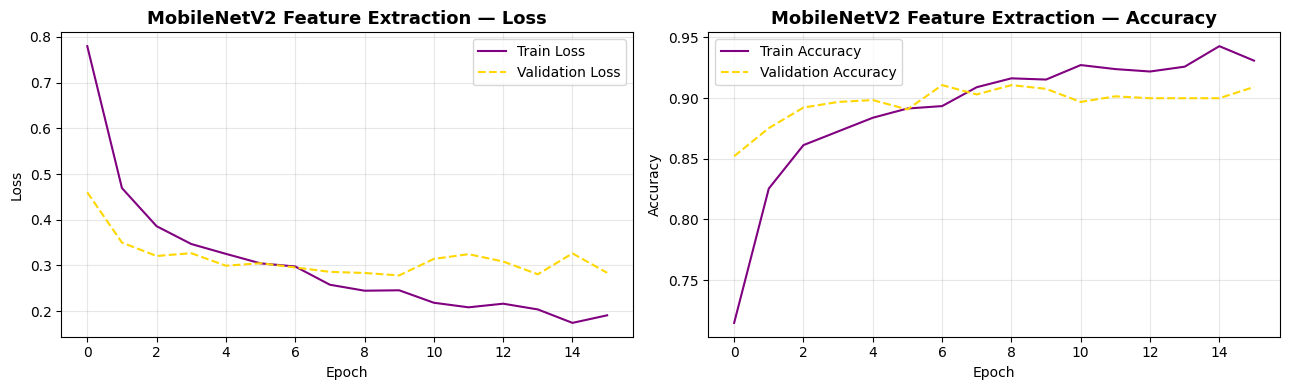


Model                            Test Accuracy    Test Loss  Train Time (s)
Baseline CNN (Scratch)                  75.65%       0.6823          408.31
Deeper CNN + Adam                       71.96%       0.7383          704.39
MobileNetV2 Feature Ext.                88.14%       0.3423          826.91


In [100]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import time
import matplotlib.pyplot as plt
import numpy as np

# Assuming IMG_SIZE and NUM_CLASSES are already defined from previous cells
# IMG_SIZE = (224, 224)
# NUM_CLASSES = 5

print("Building MobileNetV2 model for Feature Extraction...")

# Define the base MobileNetV2 model
base_model_mnv2 = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# Freeze all layers of the base model for feature extraction
for layer in base_model_mnv2.layers:
    layer.trainable = False

# Add custom classification layers on top
x = base_model_mnv2.output
x = GlobalAveragePooling2D()(x)
x = Dense(200, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

# Create the final MobileNetV2 feature extraction model
model_mnv2 = Model(inputs=base_model_mnv2.input, outputs=output)

print("MobileNetV2 model built and compiled!")

# --- Compile and Train MobileNetV2 (Feature Extraction) ---
model_mnv2.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping_mnv2 = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

print("\nTraining MobileNetV2 Feature Extraction model...")
start_mnv2 = time.time()

history_mnv2 = model_mnv2.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stopping_mnv2]
)

time_mnv2 = time.time() - start_mnv2
print(f"\n MobileNetV2 Feature Extraction Training Time: {time_mnv2:.2f} seconds")

# --- Evaluate MobileNetV2 ---
test_generator.reset()
loss_mnv2, acc_mnv2 = model_mnv2.evaluate(test_generator, verbose=0)

print("\n" + "=" * 45)
print("  MobileNetV2 Feature Extraction Results")
print("=" * 45)
print(f"  Test Loss     : {loss_mnv2:.4f}")
print(f"  Test Accuracy : {acc_mnv2 * 100:.2f}%")
print("=" * 45)

# --- Save MobileNetV2 Model ---
model_mnv2.save("mobilenetv2_transfer_learning.h5")
print("Transfer learning model saved as mobilenetv2_transfer_learning.h5")

# --- Plot Training Curves for MobileNetV2 ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_mnv2.history['loss'],     label='Train Loss',      color='purple')
axes[0].plot(history_mnv2.history['val_loss'], label='Validation Loss', color='gold', linestyle='--')
axes[0].set_title('MobileNetV2 Feature Extraction — Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_mnv2.history['accuracy'],     label='Train Accuracy',      color='purple')
axes[1].plot(history_mnv2.history['val_accuracy'], label='Validation Accuracy', color='gold', linestyle='--')
axes[1].set_title('MobileNetV2 Feature Extraction — Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("mobilenetv2_feature_extraction_curves.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Display Comprehensive Summary Table ---
# The following variables are expected to be available from previous cell executions:
# baseline_test_acc, baseline_test_loss, baseline_training_time
# acc_adam, loss_adam, time_adam

print("\n" + "=" * 65)
print(f"{'Model':<30} {'Test Accuracy':>15} {'Test Loss':>12} {'Train Time (s)':>15}")
print("=" * 65)
print(f"{'Baseline CNN (Scratch)':<30} {baseline_test_acc*100:>14.2f}% {baseline_test_loss:>12.4f} {baseline_training_time:>15.2f}")
print(f"{'Deeper CNN + Adam':<30} {acc_adam*100:>14.2f}% {loss_adam:>12.4f} {time_adam:>15.2f}")
print(f"{'MobileNetV2 Feature Ext.':<30} {acc_mnv2*100:>14.2f}% {loss_mnv2:>12.4f} {time_mnv2:>15.2f}")
print("=" * 65)


21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 295ms/step


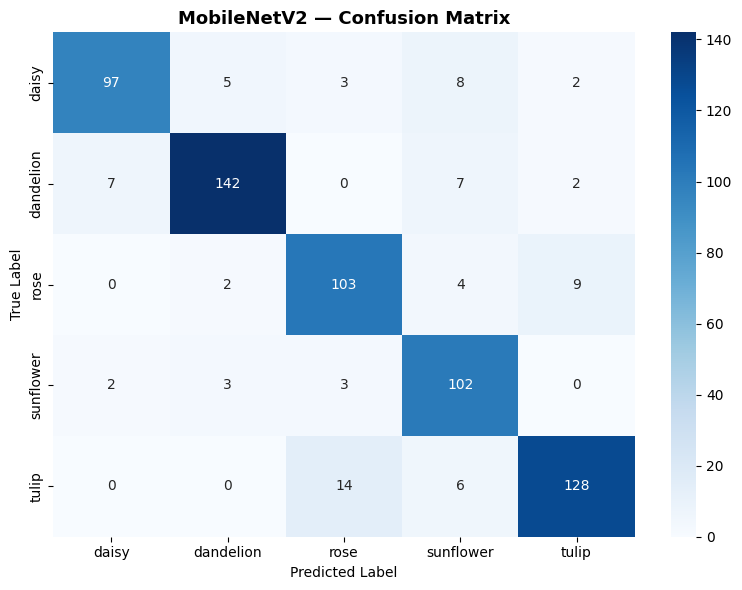

In [102]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Reset the test_generator to ensure predictions are aligned
test_generator.reset()

# Get predictions from the MobileNetV2 model
predictions_mnv2 = model_mnv2.predict(test_generator)
predicted_labels_mnv2 = np.argmax(predictions_mnv2, axis=1)
true_labels_mnv2 = test_generator.classes
class_names_mnv2 = list(test_generator.class_indices.keys())

cm_mnv2 = confusion_matrix(true_labels_mnv2, predicted_labels_mnv2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_mnv2, annot=True, fmt='d', cmap='Blues', # Using a different colormap
            xticklabels=class_names_mnv2, yticklabels=class_names_mnv2)
plt.title('MobileNetV2 — Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig("mobilenetv2_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

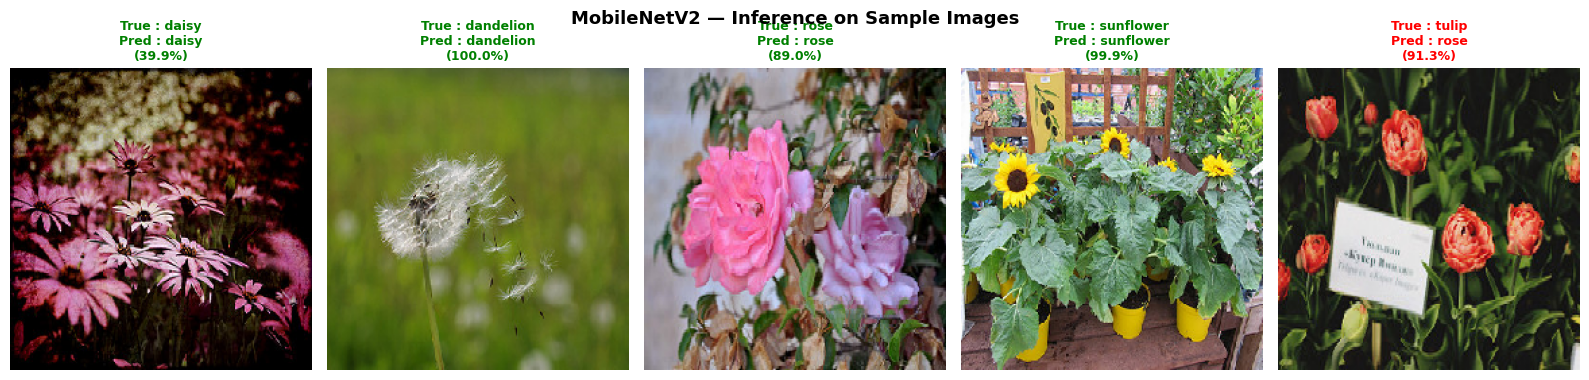


 Green = Correct   |   Red = Wrong


In [103]:
import random
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Pick 5 random images from test set
sample_images_mnv2 = []
sample_labels_mnv2 = []

for class_name in class_names_mnv2:
    class_path = os.path.join(test_dir, class_name)
    images     = os.listdir(class_path)
    img_name   = random.choice(images)
    sample_images_mnv2.append(os.path.join(class_path, img_name))
    sample_labels_mnv2.append(class_name)

# Plot predictions
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle("MobileNetV2 — Inference on Sample Images",
             fontsize=13, fontweight='bold')

for i, (img_path, true_label) in enumerate(zip(sample_images_mnv2, sample_labels_mnv2)):
    img     = keras_image.load_img(img_path, target_size=IMG_SIZE)
    img_arr = keras_image.img_to_array(img)
    img_arr = preprocess_input(img_arr)         # MobileNetV2 preprocessing
    img_arr = np.expand_dims(img_arr, axis=0)

    pred       = model_mnv2.predict(img_arr, verbose=0)
    pred_label = class_names_mnv2[np.argmax(pred)]
    confidence = np.max(pred) * 100

    axes[i].imshow(keras_image.load_img(img_path, target_size=IMG_SIZE))
    axes[i].axis('off')
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(
        f"True : {true_label}\nPred : {pred_label}\n({confidence:.1f}%)",
        fontsize=9, color=color, fontweight='bold'
    )

plt.tight_layout()
plt.savefig("mobilenetv2_inference.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n Green = Correct   |   Red = Wrong")

## Resources

Figure 8 — MobileNetV2 Feature Extraction Training and Validation Curves.

![Figure 8 — MobileNetV2 Feature Extraction Training and Validation Curves](mobilenetv2_feature_extraction_curves.png)

Figure 9 — MobileNetV2 Confusion Matrix.

![Figure 9 — MobileNetV2 Confusion Matrix](mobilenetv2_confusion_matrix.png)

Figure 10 — MobileNetV2 Sample Predictions

![Figure 10 — MobileNetV2 Sample Predictions](mobilenetv2_inference.png)